In [7]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style, FS_ANNOT_LG, FS_ANNOT_SM
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.Benchmark import db_hit_compare as dc

BENCH = config.ROOT / 'MixedEffectsModeling' / 'Benchmark'

In [18]:
# every DESeq2 design with results on disk -- ALL of these land in the result tables.
# ruvg_kN already IS "W as covariates" (design ~W_1 + ... + W_k + condition, run_deseq2.py:99);
# DESeq2/ruvg_W/ holds the W factor matrices themselves, not a separate scoreable design.
DESEQ2_DESIGNS = ['no_covariate', 'covariate', 'ruvg_k1', 'ruvg_k2', 'ruvg_k3']
# subset actually drawn in the figures -- the established comparison arm
PLOT_DESIGNS = ['covariate', 'ruvg_k1', 'ruvg_k2', 'ruvg_k3']
# venn4/upset is drawn once per RUVg design (it can only hold one at a time) -- each gets its
# own output folder, otherwise every design overwrites the previous one's plots
VENN4_DESIGNS = ['ruvg_k1', 'ruvg_k2', 'ruvg_k3']

DESIGN_COLORS = {
    'no_covariate': '#D3D3D3',  # light gray -- uncorrected, confounded
    'covariate': '#5280A6',     # steel blue -- + 10 explicit covariates
    'ruvg_k1': '#9BC4A0',       # RUVg K=1..3 -- one green ramp, darker = more W factors
    'ruvg_k2': '#70A06E',
    'ruvg_k3': '#3F6B45',
}
# normative group-combination methods (dc.GROUP_STAT_METHODS)
METHOD_COLORS = {'stouffer': '#B61518', 'extreme_mwu': '#E8A33D',
                 'wolfers_chi2': '#6B4C9A', 'wolfers_prop': '#2E8B92'}

DESIGN_LEVEL_LABELS = {
    'no_covariate': 'DESeq2 (No covariates)', 'covariate': 'DESeq2 (+ 10 Covariates)',
    'ruvg_k1': 'DESeq2 (+ RUVg K=1)', 'ruvg_k2': 'DESeq2 (+ RUVg K=2)', 'ruvg_k3': 'DESeq2 (+ RUVg K=3)',
}

# phenotype -> contributing study/author labels (same min_n=3 filter as dc.stouffer_group_z,
# e.g. Liver Cancer pools Chen et al. + Roskams-Hieter B et al.; Block et al. dropped, n=2)
sm = pd.read_csv(dc.ZDIR / 'sample_meta.csv')
sm['study'] = sm['batch'].str.replace(r'_Batch_\d+$', '', regex=True)
study_counts = sm[sm.ood_keep].groupby(['phenotype', 'study']).size()
pheno_studies = {}
for (pheno, study), n in study_counts[study_counts >= 3].items():
    pheno_studies.setdefault(pheno, []).append(study.replace(' et al.', ''))


def pheno_label(p):
    studies = sorted(pheno_studies.get(p, []))
    return f"{p} ({', '.join(studies)})" if studies else p

In [9]:
# extreme_mwu: Rutherford 2023 eLife, |Z|>2 vs HC via Mann-Whitney U
# wolfers_chi2: Wolfers 2018 JAMA Psychiatry, |Z|>2.6 binarized, chi-square on the group x extreme table
GROUP_METHODS = ['stouffer', 'extreme_mwu', 'wolfers_chi2']
GENE_Z_PATHS = {m: BENCH / f"group_level_z_test_multidesign{'' if m == 'stouffer' else '_' + m}.csv" for m in GROUP_METHODS}

gene_z_by_method = {}
for m in GROUP_METHODS:
    path = GENE_Z_PATHS[m]
    if path.exists():
        gene_z_by_method[m] = pd.read_csv(path)
    else:
        parts = [dc.group_level_z_test(deseq2_design=d, method=m) for d in DESEQ2_DESIGNS]
        # normative_group_* rows are identical across calls (design only affects the deseq2_* rows) -- keep once
        norm_label = parts[0].method.iloc[0]
        part = pd.concat([parts[0]] + [p[p.method != norm_label] for p in parts[1:]], ignore_index=True)
        part.to_csv(path, index=False)
        gene_z_by_method[m] = part

# combine across methods: deseq2_* rows only from the first method (identical across methods, not recomputed)
gene_z = pd.concat(
    [gene_z_by_method[GROUP_METHODS[0]]] +
    [df[df.method.str.startswith('normative_group')] for df in list(gene_z_by_method.values())[1:]],
    ignore_index=True)

print('significant phenotypes (hypergeometric padj<0.05) by method x q:')
display(gene_z.groupby(['method', 'q'])['sig_fdr05'].agg(n_sig='sum', n_total='size'))

significant phenotypes (hypergeometric padj<0.05) by method x q:


n_sig  n_total
method               q                   
deseq2_covariate     0.05      4       13
                     0.10      5       13
                     0.15      5       13
                     0.20      4       13
deseq2_no_covariate  0.05      9       13
                     0.10      9       13
                     0.15      7       13
                     0.20      9       13
deseq2_ruvg_k1       0.05      8       13
                     0.10      9       13
                     0.15      9       13
                     0.20     10       13
deseq2_ruvg_k2       0.05      5       13
                     0.10      5       13
                     0.15      6       13
                     0.20      7       13
deseq2_ruvg_k3       0.05      3       13
                     0.10      3       13
                     0.15      4       13
                     0.20      3       13
normative_group_chi2 0.05      0       14
                     0.10      0       14
                     0.15      0       14
                     0.20      0       14
normative_group_mwu  0.05      5       14
                     0.10      5       14
                     0.15      5       14
                     0.20      5       14
normative_group_z    0.05      7       14
                     0.10      8       14
                     0.15      8       14
                     0.20      8       14

In [10]:
q05 = gene_z[gene_z.q == 0.05].sort_values(['phenotype', 'method']).reset_index(drop=True)
display(q05[['phenotype', 'method', 'n_sig', 'overlap', 'ref_size', 'pval', 'padj', 'sig_fdr05']])

,phenotype,method,n_sig,overlap,ref_size,pval,padj,sig_fdr05
0,Colorectal Cancer,deseq2_covariate,49,2,300,1.690814e-01,0.307903,False
1,Colorectal Cancer,deseq2_no_covariate,10041,192,300,1.559889e-06,0.000006,True
2,Colorectal Cancer,deseq2_ruvg_k1,611,19,300,2.498277e-03,0.004906,True
3,Colorectal Cancer,deseq2_ruvg_k2,88,1,300,7.388209e-01,0.812814,False
4,Colorectal Cancer,deseq2_ruvg_k3,93,3,300,1.662501e-01,0.318546,False
...,...,...,...,...,...,...,...,...
102,Tuberculosis,deseq2_ruvg_k2,782,29,300,8.473015e-06,0.000044,True
103,Tuberculosis,deseq2_ruvg_k3,136,10,300,4.238962e-05,0.000192,True
104,Tuberculosis,normative_group_chi2,896,21,300,3.146288e-02,0.086435,False
105,Tuberculosis,normative_group_mwu,1270,43,300,5.614736e-07,0.000004,True


In [11]:
# per-(phenotype, study) breakdown at q=0.05, both group methods -- phenotypes pooling multiple
# cohorts (e.g. Liver Cancer = Chen et al. + Roskams-Hieter B et al.) get one row per study instead
# of one combined bar.
import pickle
from scipy.stats import hypergeom, norm
from MixedEffectsModeling.core.calibration import bh_fdr_reject

ref = dc.load_reference()
sym_of = dc.ensg_to_symbol()
gene_names = pickle.load(open(dc.ZDIR / 'gene_names.pkl', 'rb'))
sym_arr = sym_of.reindex(gene_names).values
N_genes = len(gene_names)

rows = []
norm_sig_by_row = {m: {} for m in GROUP_METHODS}
nocov_sig_by_row, design_sig_by_row = {}, {d: {} for d in DESEQ2_DESIGNS}
group_z_by_method = {m: dc.group_stat_cached(m) for m in GROUP_METHODS}  # {(pheno, study): gz}, min_n=3 already applied

for m in GROUP_METHODS:
    label = dc.GROUP_STAT_LABELS[m]
    for (pheno, study), gz in group_z_by_method[m].items():
        dref = ref.get(pheno, set())
        if not dref:
            continue
        finite = np.isfinite(gz)
        p = np.full(len(gz), np.nan)
        p[finite] = 2 * norm.sf(np.abs(gz[finite]))
        reject = np.zeros(len(gz), dtype=bool)
        reject[finite] = bh_fdr_reject(p[finite], q=0.05)
        sig = {s for s in sym_arr[reject] if pd.notna(s)}
        K, n, x = len(dref), len(sig), len(sig & dref)
        pval = hypergeom.sf(x - 1, N_genes, K, n) if n > 0 else np.nan
        rows.append(dict(phenotype=pheno, study=study, method=label, n_sig=n, n_db=x, ref_size=K, pval=pval))
        norm_sig_by_row[m][(pheno, study)] = sig

sym_of_v = sym_of.copy()
sym_of_v.index = sym_of_v.index.str.split('.').str[0]
for design in DESEQ2_DESIGNS:
    for (study, pheno), res in dc.deseq2_study_results(design).items():
        dref = ref.get(pheno, set())
        if not dref:
            continue
        sig = set(sym_of_v.reindex(res.index[res['padj'] < 0.05]).dropna())
        K, n, x = len(dref), len(sig), len(sig & dref)
        pval = hypergeom.sf(x - 1, N_genes, K, n) if n > 0 else np.nan
        rows.append(dict(phenotype=pheno, study=study, method=f'deseq2_{design}', n_sig=n, n_db=x, ref_size=K, pval=pval))
        design_sig_by_row[design][(pheno, study)] = sig
        if design == 'no_covariate':
            nocov_sig_by_row[(pheno, study)] = sig

# split each method's hits by whether DESeq2(no covariate) also flags them -- unique = independent signal
for m in GROUP_METHODS:
    label = dc.GROUP_STAT_LABELS[m]
    for (pheno, study), norm_sig in norm_sig_by_row[m].items():
        dref = ref.get(pheno, set())
        nocov_sig = nocov_sig_by_row.get((pheno, study), set())
        for tag, s in [(f'{label}_unique', norm_sig - nocov_sig), (f'{label}_overlap', norm_sig & nocov_sig)]:
            K, n, x = len(dref), len(s), len(s & dref)
            pval = hypergeom.sf(x - 1, N_genes, K, n) if n > 0 else np.nan
            rows.append(dict(phenotype=pheno, study=study, method=tag, n_sig=n, n_db=x, ref_size=K, pval=pval))

gene_z_study = pd.DataFrame(rows)
gene_z_study['has_ot_ref'] = gene_z_study['ref_size'] > 0
display(gene_z_study[gene_z_study.phenotype == 'Liver Cancer'])

,phenotype,study,method,n_sig,n_db,ref_size,pval,has_ot_ref
4,Liver Cancer,Chen et al.,normative_group_z,2041,36,300,1.842272e-01,True
5,Liver Cancer,Roskams-Hieter B et al.,normative_group_z,4078,102,300,3.140051e-08,True
19,Liver Cancer,Chen et al.,normative_group_mwu,2227,46,300,1.737245e-02,True
20,Liver Cancer,Roskams-Hieter B et al.,normative_group_mwu,996,26,300,4.870208e-03,True
34,Liver Cancer,Chen et al.,normative_group_chi2,6020,98,300,2.026781e-01,True
35,Liver Cancer,Roskams-Hieter B et al.,normative_group_chi2,1482,18,300,8.620552e-01,True
50,Liver Cancer,Chen et al.,deseq2_no_covariate,1269,34,300,8.520094e-04,True
57,Liver Cancer,Roskams-Hieter B et al.,deseq2_no_covariate,15,0,300,1.000000e+00,True
64,Liver Cancer,Chen et al.,deseq2_covariate,16,1,300,2.162407e-01,True
71,Liver Cancer,Roskams-Hieter B et al.,deseq2_covariate,28,2,300,6.647646e-02,True


In [12]:
from upsetplot import UpSet, from_contents

# venn4 = normative per-patient K=1 union vs DESeq2 no_cov / covariate / ONE RUVg design.
# design_c is the only free knob, so loop it and give each design its own folder -- a single fixed
# save path meant each design silently overwrote the previous one's plots.
venn4_by_design = {}
for design_c in VENN4_DESIGNS:
    v4 = dc.gene_venn_sets_4way(design_c=design_c)
    venn4_by_design[design_c] = v4
    figdir = BENCH / 'Figures' / 'venn4' / design_c
    figdir.mkdir(parents=True, exist_ok=True)
    for ph in sorted(v4, key=lambda p: -len(v4[p]['normative'])):
        sets = {k: s for k, s in v4[ph].items() if len(s) > 0}
        up = UpSet(from_contents(sets), subset_size='count', show_counts=True, sort_by='cardinality')
        fig = plt.figure(figsize=(9, 5))
        up.plot(fig=fig)
        fig.suptitle(f'{ph} -- {design_c}')
        fig.savefig(figdir / f"upset_{ph.replace('/', '-').replace(' ', '_')}.png", dpi=150)
        plt.close(fig)  # saved to file only -- not rendered inline
print({d: len(v) for d, v in venn4_by_design.items()}, '-> Figures/venn4/<design>/upset_*.png')

/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

{'ruvg_k1': 17, 'ruvg_k2': 17, 'ruvg_k3': 17} -> Figures/venn4/<design>/upset_*.png


/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mjcho/miniconda3/envs/scRNA/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linew

In [13]:
venn4_by_design = globals().get('venn4_by_design') or {
    d: dc.gene_venn_sets_4way(design_c=d) for d in VENN4_DESIGNS}


def jacc(a, b):
    return len(a & b) / len(a | b) if (a | b) else float("nan")


parts = []
for design_c, venn4_all in venn4_by_design.items():
    ruvg_key = dc.DESIGN_LABELS[design_c]
    rows = []
    for ph, s in venn4_all.items():
        n, c, r, m = s["deseq2_no_cov"], s["deseq2_covariate"], s[ruvg_key], s["normative"]
        rows.append(dict(
            ruvg_design=design_c, phenotype=ph,
            n_no_cov=len(n), n_cov=len(c), n_ruvg=len(r), n_normative=len(m),
            deseq2_3way_overlap=len(n & c & r), all4_overlap=len(n & c & r & m),
            jacc_norm_nocov=jacc(m, n), jacc_norm_cov=jacc(m, c), jacc_norm_ruvg=jacc(m, r),
            norm_nocov_bias=jacc(m, n) / jacc(m, c) if jacc(m, c) > 0 else float("inf"),
            n_norm_unique=len(m - n - c - r), norm_unique_frac=len(m - n - c - r) / len(m) if m else float("nan"),
        ))
    t = pd.DataFrame(rows).sort_values("norm_nocov_bias", ascending=False).reset_index(drop=True)
    t.to_csv(BENCH / f"venn4_summary_{design_c}.csv", index=False)  # one file per design, no clobbering
    parts.append(t)

venn4_table = pd.concat(parts, ignore_index=True)
venn4_table.to_csv(BENCH / "venn4_summary.csv", index=False)  # combined, carries a ruvg_design column
venn4_table

,ruvg_design,phenotype,n_no_cov,n_cov,n_ruvg,n_normative,deseq2_3way_overlap,all4_overlap,jacc_norm_nocov,jacc_norm_cov,jacc_norm_ruvg,norm_nocov_bias,n_norm_unique,norm_unique_frac
0,ruvg_k1,Esophagus Cancer,432,24,533,732,18,0,0.005181,0.000000,0.007166,inf,720,0.983607
1,ruvg_k1,MGUS,1032,19,2,511,0,0,0.003251,0.000000,0.000000,inf,506,0.990215
2,ruvg_k1,ME/CFS,1332,3,8,594,1,0,0.045035,0.000000,0.008375,inf,507,0.853535
3,ruvg_k1,Colorectal Cancer,10041,49,611,2385,14,2,0.133966,0.000822,0.040639,162.902719,878,0.368134
4,ruvg_k1,Pancreatitis,2199,16,1112,2698,5,1,0.054252,0.000737,0.039847,73.565554,2412,0.893996
5,ruvg_k1,Pancreatic Cancer,2292,38,1077,3567,14,5,0.098219,0.003340,0.061728,29.408497,2989,0.837959
6,ruvg_k1,Liver Cancer,1280,44,416,4339,9,5,0.095108,0.003664,0.037983,25.958585,3743,0.862641
7,ruvg_k1,Lung Cancer,7600,99,727,2887,52,19,0.111382,0.009466,0.057034,11.766707,1767,0.612054
8,ruvg_k1,Pre-eclampsia,1241,109,339,1484,26,4,0.055792,0.012071,0.032276,4.621954,1309,0.882075
9,ruvg_k1,Stomach Cancer,7618,210,475,2102,78,24,0.062527,0.017606,0.031212,3.551552,1506,0.716461


In [14]:
PATH_GSEA_PATHS = {m: BENCH / f"pathway_gsea_db_hit_rates_multidesign{'' if m == 'stouffer' else '_' + m}.csv" for m in GROUP_METHODS}

path_gsea_by_method = {}
for m in GROUP_METHODS:
    path = PATH_GSEA_PATHS[m]
    if path.exists():
        path_gsea_by_method[m] = pd.read_csv(path)
    else:
        parts = [dc.group_level_pathway_gsea(save=False, deseq2_design=d, method=m) for d in DESEQ2_DESIGNS]
        # normative_group_gsea* rows are identical across calls -- keep once
        part = pd.concat(
            [parts[0]] + [p[~p.method.str.startswith('normative_group_gsea')] for p in parts[1:]],
            ignore_index=True)
        part.to_csv(path, index=False)
        path_gsea_by_method[m] = part

path_gsea = pd.concat(
    [path_gsea_by_method[GROUP_METHODS[0]]] +
    [df[df.method.str.startswith('normative_group_gsea')] for df in list(path_gsea_by_method.values())[1:]],
    ignore_index=True)

display(path_gsea[path_gsea.has_ot_ref].sort_values(['phenotype', 'method']).reset_index(drop=True))

2026-09-08 19:37:41,203 [WARNING] Duplicated values found in preranked stats: 98.78% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
/project/cfRNA_NormativeModeling/MixedEffectsModeling/Benchmark/db_hit_compare.py:956: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rnk_df = rnk_df[pd.notna(rnk_df.index)].groupby(level=0).mean().reindex(universe_syms)
/project/cfRNA_NormativeModeling/MixedEffectsModeling/Benchmark/db_hit_compare.py:956: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rnk_df = rnk_df[pd.notna(rnk_df.index)].groupby(level=0).mean().reindex(universe_syms)


,phenotype,method,n_sig,n_db,db_hit_rate,has_ot_ref
0,Colorectal Cancer,deseq2_cov_gsea,61,25,0.410,True
1,Colorectal Cancer,deseq2_cov_gsea_q025,252,110,0.437,True
2,Colorectal Cancer,deseq2_no_cov_gsea,31,13,0.419,True
3,Colorectal Cancer,deseq2_no_cov_gsea_q025,250,80,0.320,True
4,Colorectal Cancer,deseq2_ruvg_k1_gsea,61,9,0.148,True
...,...,...,...,...,...,...
209,Tuberculosis,normative_group_gsea_chi2,5,2,0.400,True
210,Tuberculosis,normative_group_gsea_chi2_q025,318,69,0.217,True
211,Tuberculosis,normative_group_gsea_mwu,274,85,0.310,True
212,Tuberculosis,normative_group_gsea_mwu_q025,802,223,0.278,True


In [15]:
# per-(phenotype, study) breakdown, both group methods, mirroring the gene-level cell above --
# reuses cached GSEA results (gsea_cache/) computed by path-compute, so this is fast (no GSEA rerun).
from MixedEffectsModeling.PerSamplePathwayAnalysis.pathway_convergence import collapse_to_symbols, load_pathway_library, load_symbol_vocab

universe_syms, sym2idx, col2sym = load_symbol_vocab(None)
terms, M = load_pathway_library()
N_syms = len(universe_syms)
ref_path = {ph: dc.reference_pathways(syms, sym2idx, terms, M) for ph, syms in ref.items()}

rows = []
norm_path_sig_by_row = {m: {} for m in GROUP_METHODS}
nocov_path_sig_by_row = {}
path_design_sig_by_row = {d: {} for d in DESEQ2_DESIGNS}

for m in GROUP_METHODS:
    label = dc.GROUP_STAT_GSEA_LABELS[m]
    for (pheno, study), gz in group_z_by_method[m].items():
        if not ref_path.get(pheno):
            continue
        Zu, Fm = collapse_to_symbols(gz[None, :], col2sym, N_syms)
        rnk = np.where(Fm[0] > 0, Zu[0], np.nan)
        res2d = dc._cached_gsea(dc.gsea_cache_key(m, pheno, study), rnk, terms, M, universe_syms)
        sig = set(res2d.loc[res2d['FDR q-val'] < 0.05, 'Term'])
        d = dc.db_hit_row(pheno, label, sig, ref_path)
        d['study'] = study
        rows.append(d)
        norm_path_sig_by_row[m][(pheno, study)] = sig

deseq2_summary = pd.read_csv(dc.DESEQ_DIR / 'summary.csv')
for design in DESEQ2_DESIGNS:
    method = f"{dc.DESIGN_LABELS[design]}_gsea"
    for _, r in deseq2_summary[deseq2_summary.design == design].iterrows():
        pheno, study = r.phenotype, r.study
        if not ref_path.get(pheno):
            continue
        path = dc.DESEQ_DIR / design / f"{dc.deseq2_tag(study, pheno)}.csv"
        if not path.exists():
            continue
        res = pd.read_csv(path, index_col=0)
        res.index = res.index.str.split('.').str[0]
        stat = res['stat'].dropna()
        syms = sym_of.reindex(stat.index)
        rnk_df = pd.Series(stat.values, index=syms.values)
        rnk_df = rnk_df[pd.notna(rnk_df.index)].groupby(level=0).mean().reindex(universe_syms)
        res2d = dc._cached_gsea(f"{design}__{dc.deseq2_tag(study, pheno)}", rnk_df.values, terms, M, universe_syms)
        sig = set(res2d.loc[res2d['FDR q-val'] < 0.05, 'Term'])
        d = dc.db_hit_row(pheno, method, sig, ref_path)
        d['study'] = study
        rows.append(d)
        path_design_sig_by_row[design][(pheno, study)] = sig
        if design == 'no_covariate':
            nocov_path_sig_by_row[(pheno, study)] = sig

for m in GROUP_METHODS:
    label = dc.GROUP_STAT_GSEA_LABELS[m]
    for (pheno, study), norm_sig in norm_path_sig_by_row[m].items():
        nocov_sig = nocov_path_sig_by_row.get((pheno, study), set())
        for tag, s in [(f'{label}_unique', norm_sig - nocov_sig), (f'{label}_overlap', norm_sig & nocov_sig)]:
            d = dc.db_hit_row(pheno, tag, s, ref_path)
            d['study'] = study
            rows.append(d)

path_gsea_study = pd.DataFrame(rows)
display(path_gsea_study[path_gsea_study.phenotype == 'Liver Cancer'])

/tmp/ipykernel_994927/945341702.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rnk_df = rnk_df[pd.notna(rnk_df.index)].groupby(level=0).mean().reindex(universe_syms)
/tmp/ipykernel_994927/945341702.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rnk_df = rnk_df[pd.notna(rnk_df.index)].groupby(level=0).mean().reindex(universe_syms)
/tmp/ipykernel_994927/945341702.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warnin

,phenotype,method,n_sig,n_db,db_hit_rate,has_ot_ref,study
4,Liver Cancer,normative_group_gsea,513,162,0.316,True,Chen et al.
5,Liver Cancer,normative_group_gsea,17,6,0.353,True,Roskams-Hieter B et al.
19,Liver Cancer,normative_group_gsea_mwu,9,2,0.222,True,Chen et al.
20,Liver Cancer,normative_group_gsea_mwu,24,8,0.333,True,Roskams-Hieter B et al.
34,Liver Cancer,normative_group_gsea_chi2,0,0,NaN,True,Chen et al.
35,Liver Cancer,normative_group_gsea_chi2,12,1,0.083,True,Roskams-Hieter B et al.
50,Liver Cancer,deseq2_no_cov_gsea,57,11,0.193,True,Chen et al.
57,Liver Cancer,deseq2_no_cov_gsea,131,51,0.389,True,Roskams-Hieter B et al.
64,Liver Cancer,deseq2_cov_gsea,21,1,0.048,True,Chen et al.
71,Liver Cancer,deseq2_cov_gsea,32,1,0.031,True,Roskams-Hieter B et al.


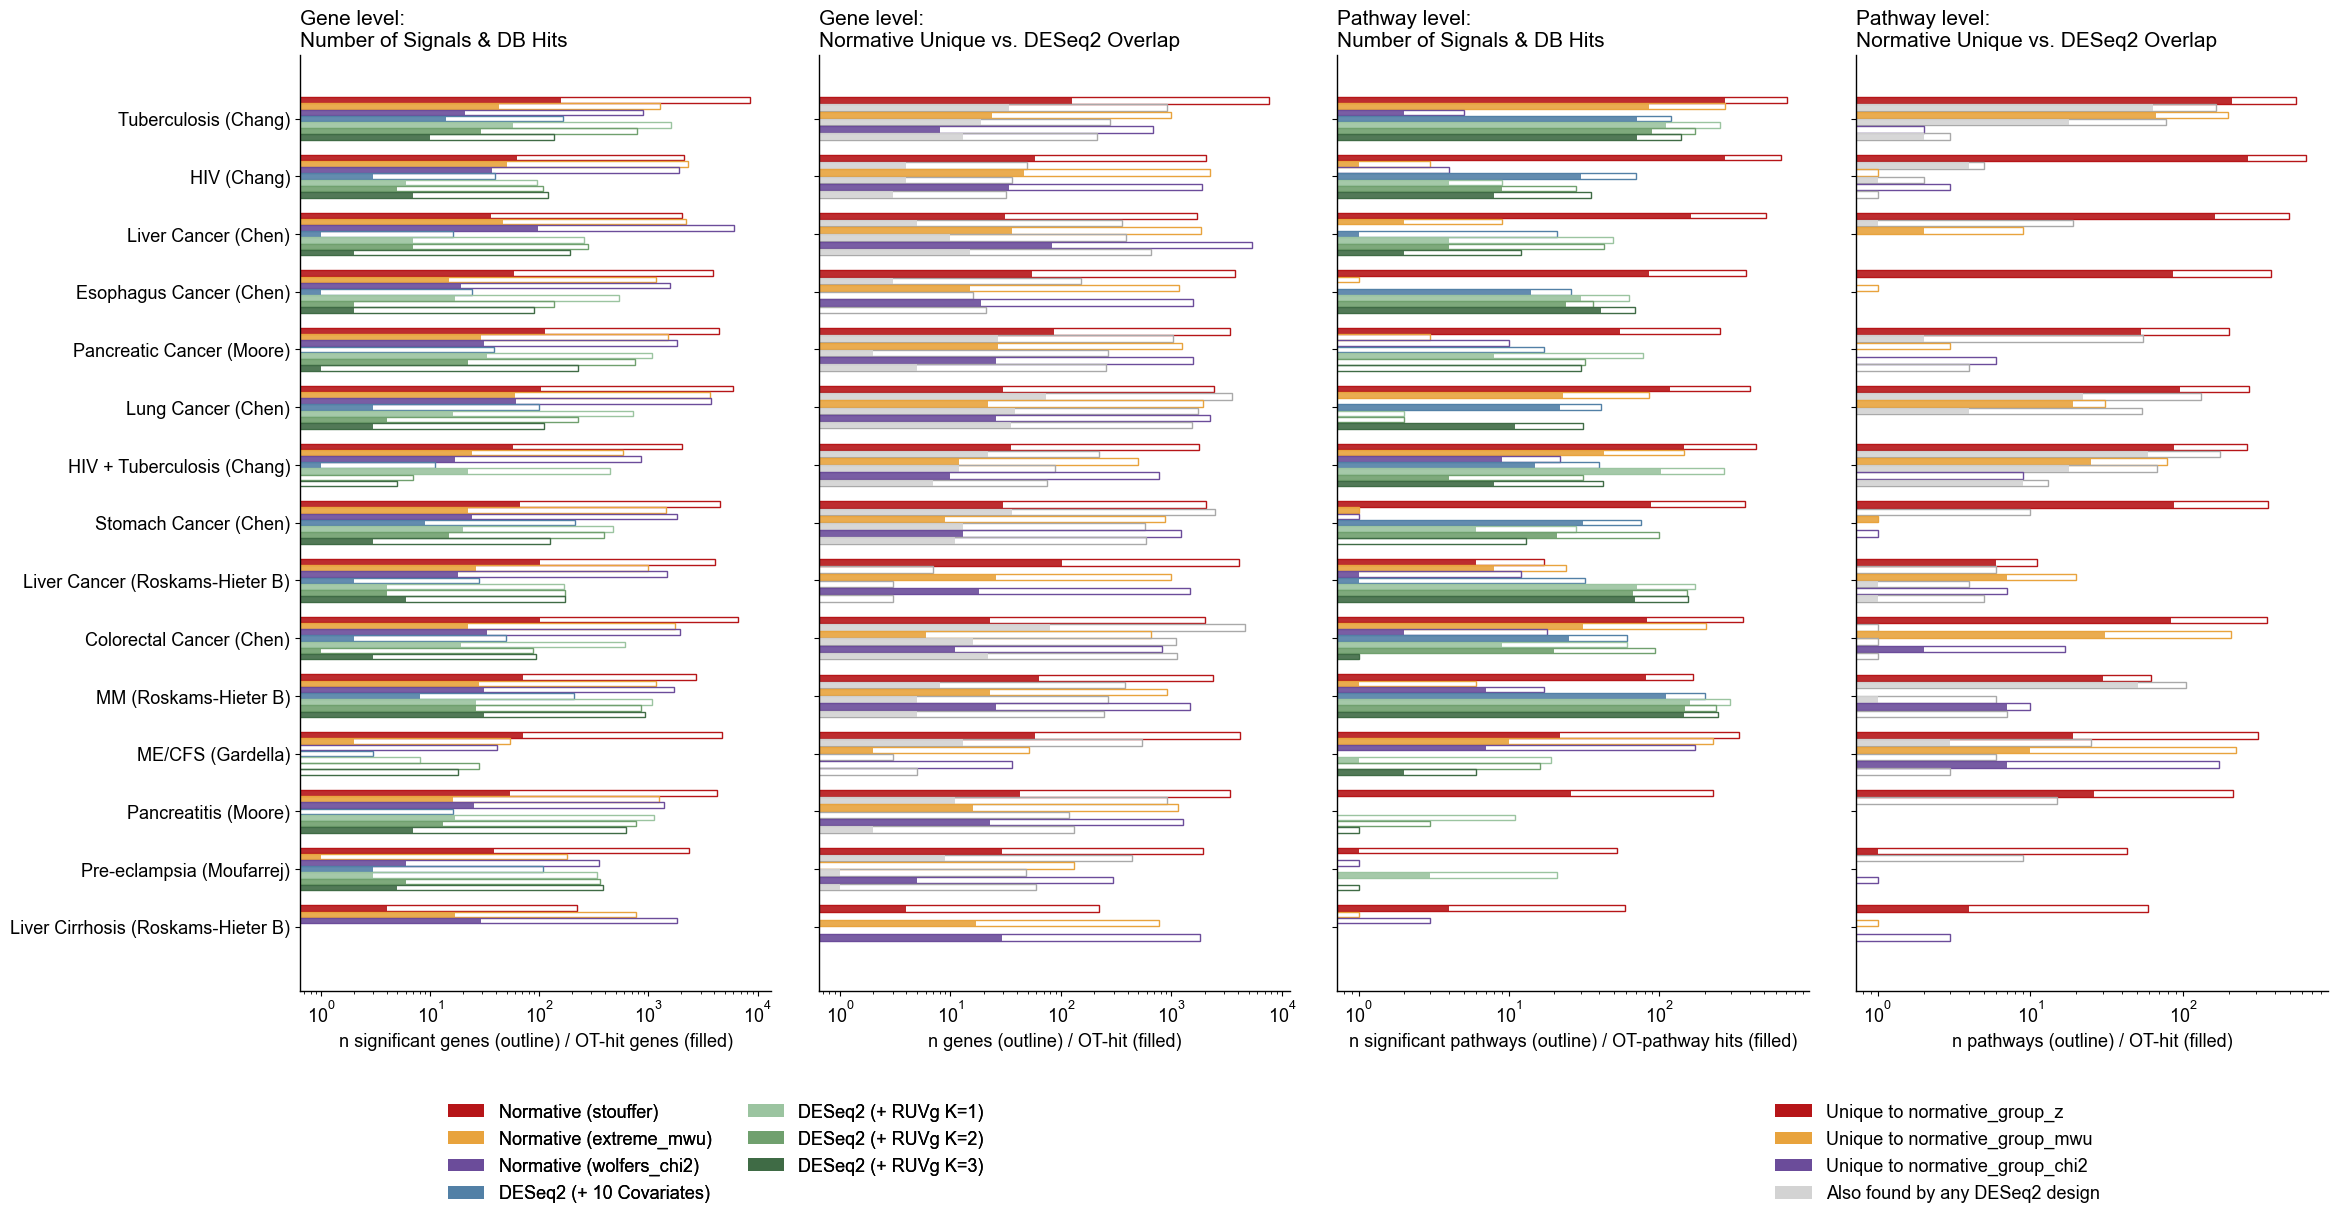

In [19]:
# combined gene + pathway view, shared y-axis (phenotype/study rows), both group methods
sub_g = gene_z_study[gene_z_study.has_ot_ref].copy()
sub_g['row_label'] = sub_g.apply(lambda r: f"{r.phenotype} ({r.study.replace(' et al.', '')})", axis=1)
sub_p = path_gsea_study[path_gsea_study.has_ot_ref].copy()
sub_p['row_label'] = sub_p.apply(lambda r: f"{r.phenotype} ({r.study.replace(' et al.', '')})", axis=1)

rank_label = dc.GROUP_STAT_LABELS[GROUP_METHODS[0]]
rank_gsea_label = dc.GROUP_STAT_GSEA_LABELS[GROUP_METHODS[0]]
score = {}
for r in set(sub_g.row_label) | set(sub_p.row_label):
    g = sub_g[(sub_g.row_label == r) & (sub_g.method == f'{rank_label}_unique')]['n_db'].sum()
    p = sub_p[(sub_p.row_label == r) & (sub_p.method == f'{rank_gsea_label}_unique')]['n_db'].sum()
    score[r] = g + p
rows_ = sorted(score, key=lambda r: (score[r], r))
y = np.arange(len(rows_))

# tables above carry every design in DESEQ2_DESIGNS; the figure draws only PLOT_DESIGNS
method_colors = {dc.GROUP_STAT_LABELS[m]: METHOD_COLORS[m] for m in GROUP_METHODS}
method_colors.update({f'deseq2_{d}': DESIGN_COLORS[d] for d in DESEQ2_DESIGNS})
gsea_colors = {dc.GROUP_STAT_GSEA_LABELS[m]: method_colors[dc.GROUP_STAT_LABELS[m]] for m in GROUP_METHODS}
gsea_colors.update({f'{dc.DESIGN_LABELS[d]}_gsea': DESIGN_COLORS[d] for d in DESEQ2_DESIGNS})

gene_methods = [dc.GROUP_STAT_LABELS[m] for m in GROUP_METHODS] + [f'deseq2_{d}' for d in PLOT_DESIGNS]
path_methods = [dc.GROUP_STAT_GSEA_LABELS[m] for m in GROUP_METHODS] + [f'{dc.DESIGN_LABELS[d]}_gsea' for d in PLOT_DESIGNS]
colors = [method_colors[m] for m in gene_methods]
path_colors = [gsea_colors[m] for m in path_methods]
level_labels = [f'Normative ({m})' for m in GROUP_METHODS] + [DESIGN_LEVEL_LABELS[d] for d in PLOT_DESIGNS]

# unique (independent of DESeq2 no-cov) vs overlap, for each group method
uniq_gene_methods, uniq_gene_colors = [], []
uniq_path_methods, uniq_path_colors = [], []
for m in GROUP_METHODS:
    label, glabel = dc.GROUP_STAT_LABELS[m], dc.GROUP_STAT_GSEA_LABELS[m]
    uniq_gene_methods += [f'{label}_unique', f'{label}_overlap']
    uniq_gene_colors += [method_colors[label], '#D3D3D3']
    uniq_path_methods += [f'{glabel}_unique', f'{glabel}_overlap']
    uniq_path_colors += [method_colors[label], '#D3D3D3']


def plot_level(ax, sub, methods, colors_, xlabel, title):
    n_m = len(methods)
    width = 0.75 / n_m
    for j, (m, c) in enumerate(zip(methods, colors_)):
        offset = ((n_m - 1) / 2 - j) * width
        n_sig_v = [sub[(sub.row_label == r) & (sub.method == m)]['n_sig'].sum() for r in rows_]
        n_db_v = [sub[(sub.row_label == r) & (sub.method == m)]['n_db'].sum() for r in rows_]
        edge_color = '#A9A9A9' if c == '#D3D3D3' else c
        ax.barh(y + offset, n_sig_v, height=width * 0.9, facecolor='none', edgecolor=edge_color, linewidth=1)
        ax.barh(y + offset, n_db_v, height=width * 0.9, facecolor=c, edgecolor='none', alpha=0.9)
    ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc='left')
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)


fig, (axG, axU_g, axP, axU_p) = plt.subplots(1, 4, figsize=(26, 12), sharey=True)
plot_level(axG, sub_g, gene_methods, colors, 'n significant genes (outline) / OT-hit genes (filled)', 'Gene level:\nNumber of Signals & DB Hits')
plot_level(axU_g, sub_g, uniq_gene_methods, uniq_gene_colors, 'n genes (outline) / OT-hit (filled)', 'Gene level:\nNormative Unique vs. DESeq2 Overlap')
plot_level(axP, sub_p, path_methods, path_colors, 'n significant pathways (outline) / OT-pathway hits (filled)', 'Pathway level:\nNumber of Signals & DB Hits')
plot_level(axU_p, sub_p, uniq_path_methods, uniq_path_colors, 'n pathways (outline) / OT-hit (filled)', 'Pathway level:\nNormative Unique vs. DESeq2 Overlap')
axG.set_yticks(y)
axG.set_yticklabels(rows_)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c) for c in colors]
uniq_handles = [plt.Rectangle((0, 0), 1, 1, facecolor=method_colors[dc.GROUP_STAT_LABELS[m]]) for m in GROUP_METHODS]
uniq_handles.append(plt.Rectangle((0, 0), 1, 1, facecolor='#D3D3D3'))
uniq_handle_labels = [f'Unique to {dc.GROUP_STAT_LABELS[m]}' for m in GROUP_METHODS] + ['Also found by any DESeq2 design']
leg1 = fig.legend(handles, level_labels, loc='upper center', bbox_to_anchor=(0.28, 0.02), ncol=2, frameon=False)
fig.legend(uniq_handles, uniq_handle_labels, loc='upper center', bbox_to_anchor=(0.75, 0.02), ncol=1, frameon=False)
fig.add_artist(leg1)

plt.subplots_adjust(left=0.12, bottom=0.1, wspace=0.1)
fig.savefig(BENCH / 'Figures' / 'group_level_comparison_combined.png', bbox_inches='tight', dpi=300)


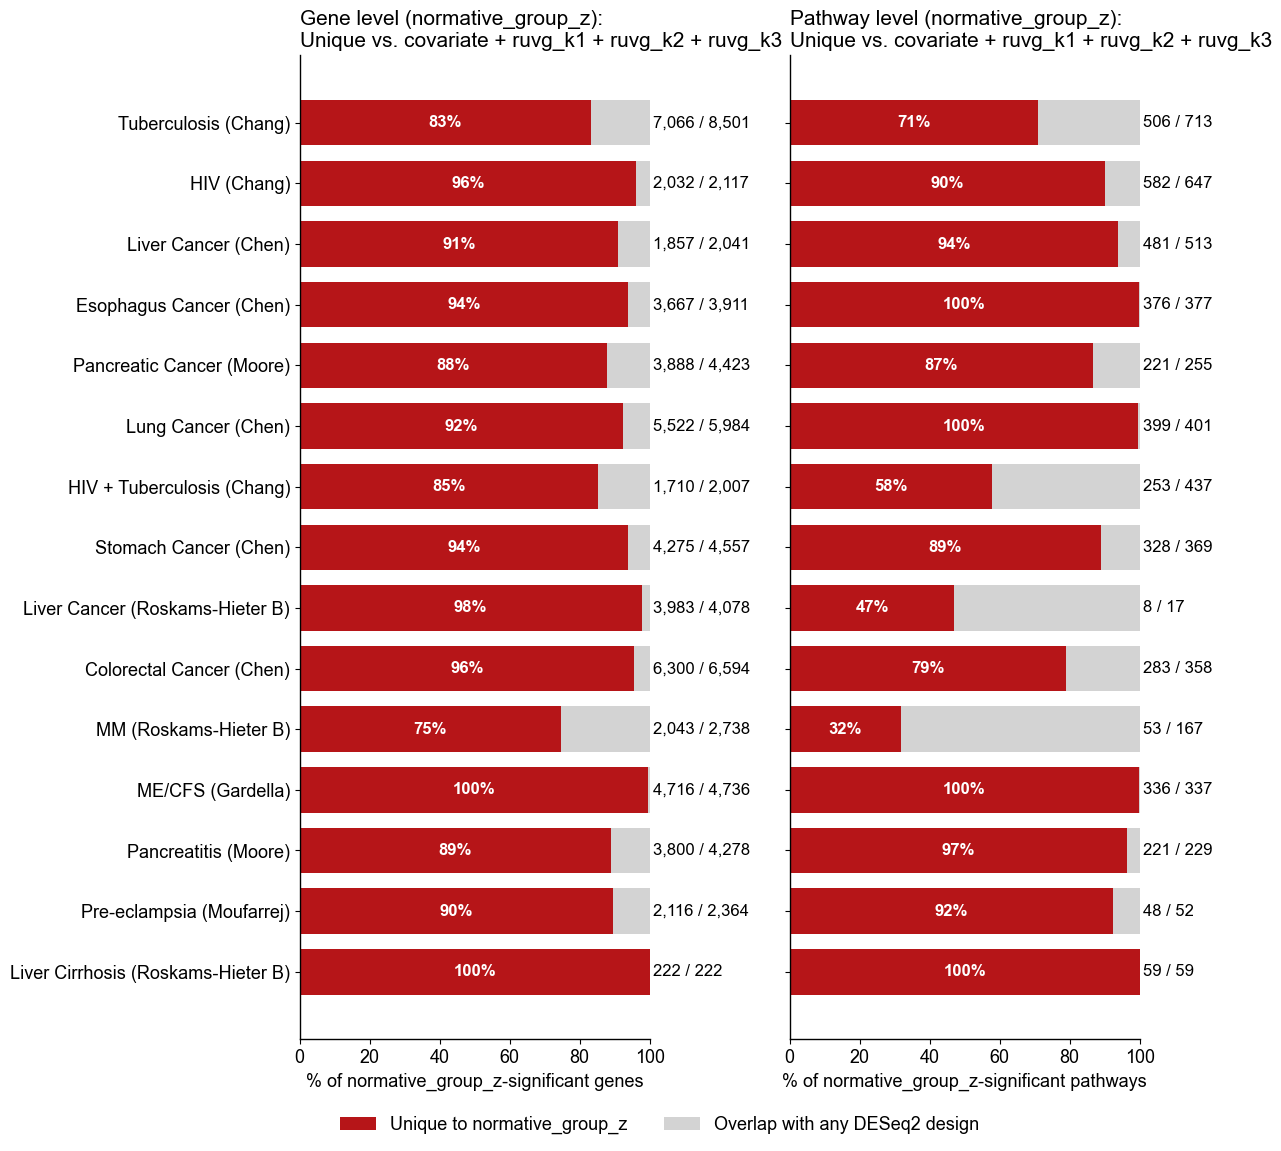

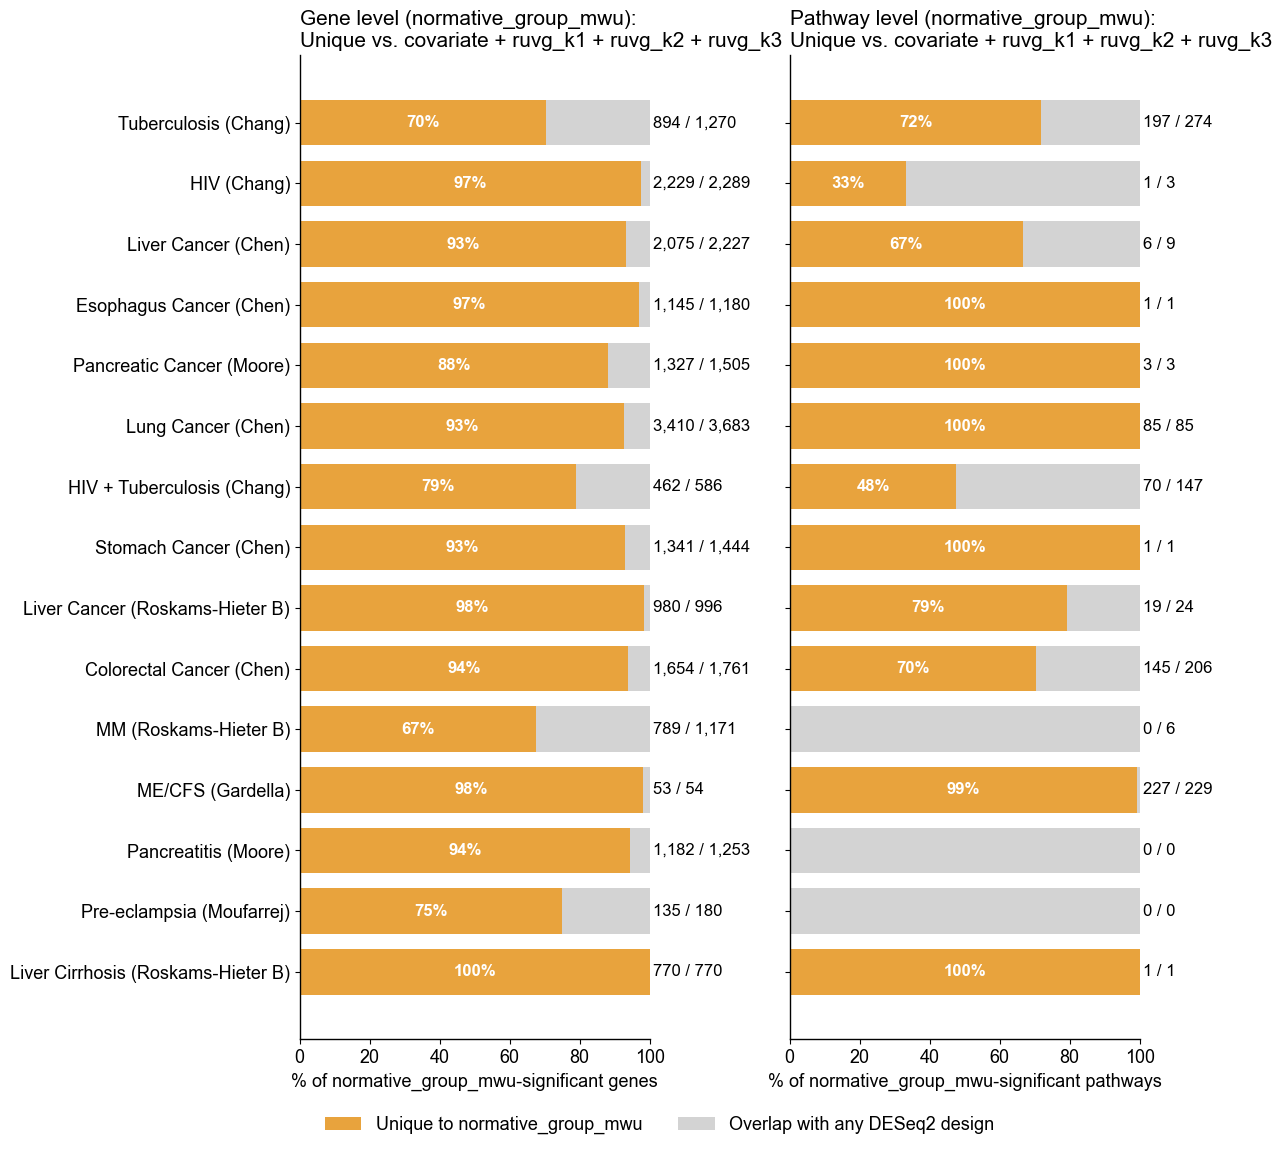

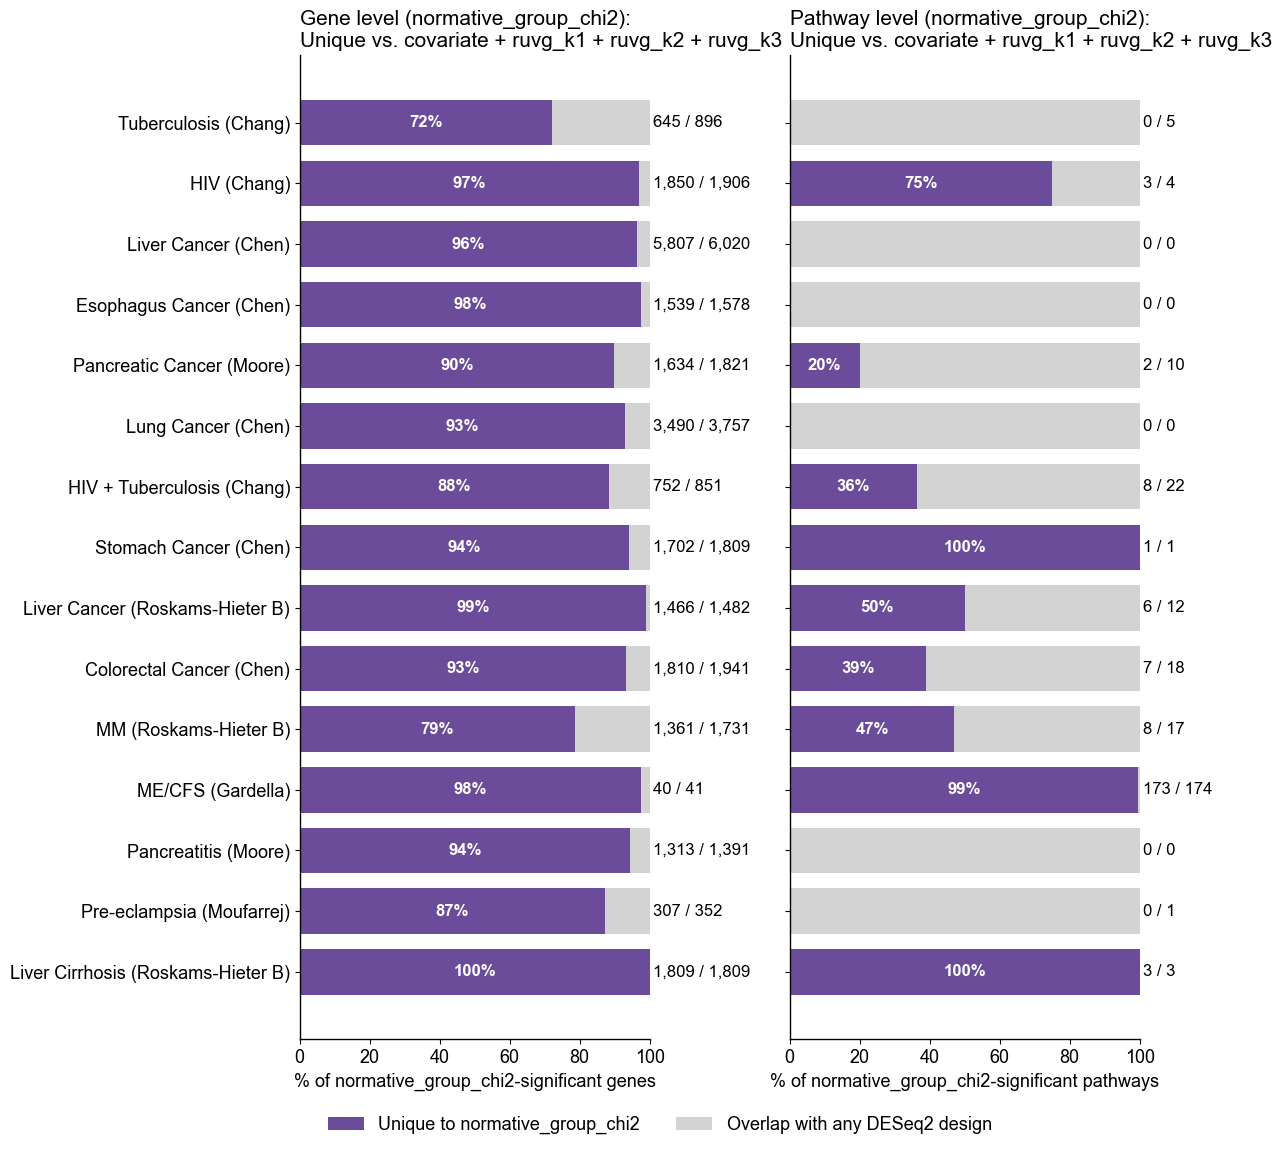

In [20]:
row_key = pd.concat([
    sub_g[['row_label', 'phenotype', 'study']],
    sub_p[['row_label', 'phenotype', 'study']]
]).drop_duplicates('row_label').set_index('row_label')


def unique_frac(sig_by_row, design_sig_by_row, key):
    norm_sig = sig_by_row.get(key)
    if not norm_sig:
        return np.nan, 0, 0
    other = set()
    for d in PLOT_DESIGNS:  # figure arm only -- widen to DESEQ2_DESIGNS for the all-design cut
        other |= design_sig_by_row[d].get(key, set())

    n_uniq = len(norm_sig - other)
    n_total = len(norm_sig)
    return 100 * n_uniq / n_total, n_uniq, n_total


def plot_unique(ax, uniq, n_uniq, n_total, xlabel, title, color):
    uniq = np.nan_to_num(uniq)
    ax.barh(y, uniq, color=color, label='Unique (missed by every plotted DESeq2 design)', height=0.75)
    ax.barh(y, 100 - uniq, left=uniq, color='#D3D3D3', label='Overlaps >=1 DESeq2 design', height=0.75)

    for i, (u, nu, nt) in enumerate(zip(uniq, n_uniq, n_total)):
        if u >= 5:
            ax.text(u / 2, i, f'{u:.0f}%', va='center', ha='center', color='white', fontweight='bold', fontsize=FS_ANNOT_LG)
        elif u > 0:
            ax.text(u / 2, i, f'{u:.0f}%', va='center', ha='center', color='black', fontsize=FS_ANNOT_LG)

        ax.text(101, i, f'{nu:,} / {nt:,}', va='center', ha='left', fontsize=FS_ANNOT_LG)

    ax.set_xlabel(xlabel)
    ax.set_title(title, loc='left')
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)


# one figure per group method, saved into its own Figures/<method>/ subfolder --
# same DESeq2-uniqueness question, method-specific normative_sig set
for m in GROUP_METHODS:
    label = dc.GROUP_STAT_LABELS[m]
    method_figdir = BENCH / 'Figures' / m
    method_figdir.mkdir(parents=True, exist_ok=True)

    gene_uniq, gene_n_uniq, gene_n_total = [], [], []
    path_uniq, path_n_uniq, path_n_total = [], [], []
    for r in rows_:
        key = (row_key.loc[r, 'phenotype'], row_key.loc[r, 'study'])
        u, nu, nt = unique_frac(norm_sig_by_row[m], design_sig_by_row, key)
        gene_uniq.append(u); gene_n_uniq.append(nu); gene_n_total.append(nt)

        u, nu, nt = unique_frac(norm_path_sig_by_row[m], path_design_sig_by_row, key)
        path_uniq.append(u); path_n_uniq.append(nu); path_n_total.append(nt)

    color = method_colors[label]
    fig, (axG, axP) = plt.subplots(1, 2, figsize=(12, 12), sharey=True)
    plot_unique(axG, gene_uniq, gene_n_uniq, gene_n_total, f'% of {label}-significant genes', f'Gene level ({label}):\nUnique vs. ' + ' + '.join(PLOT_DESIGNS), color)
    plot_unique(axP, path_uniq, path_n_uniq, path_n_total, f'% of {label}-significant pathways', f'Pathway level ({label}):\nUnique vs. ' + ' + '.join(PLOT_DESIGNS), color)

    axG.set_yticks(y)
    axG.set_yticklabels(rows_)

    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c) for c in [color, '#D3D3D3']]
    fig.legend(handles, [f'Unique to {label}', 'Overlap with any DESeq2 design'], loc='upper center', bbox_to_anchor=(0.5, 0.01), ncol=2, frameon=False)
    plt.subplots_adjust(left=0.2, bottom=0.06, wspace=0.4)
    fig.savefig(method_figdir / 'venn4_unique_fraction.png', bbox_inches='tight', dpi=300)